# Lab 07B — Tree Layout, Adjacency Matrix, Implicit Presentation (Solution)

Notebook này bổ sung cho Lab 07: tập trung vào các biểu diễn thay thế cho graph/tree dữ liệu.

## 0) Setup

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import plotly.express as px

## 1) Tree layout (explicit hierarchy)

In [2]:
tree_edges = [
    ("Root", "A"), ("Root", "B"),
    ("A", "A1"), ("A", "A2"),
    ("B", "B1"), ("B", "B2"),
    ("B2", "B21"),
]
T = nx.DiGraph()
T.add_edges_from(tree_edges)
T.number_of_nodes(), T.number_of_edges()

(8, 7)

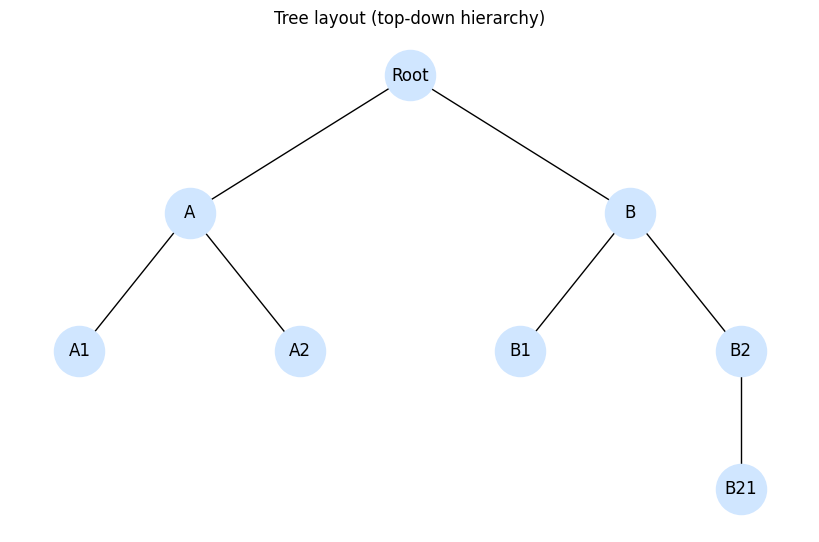

In [3]:
def hierarchy_pos(graph, root, width=1.0, vert_gap=0.2, vert_loc=0, xcenter=0.5, pos=None, parent=None):
    if pos is None:
        pos = {root: (xcenter, vert_loc)}
    children = list(graph.successors(root))
    if not children:
        return pos
    dx = width / len(children)
    nextx = xcenter - width / 2 - dx / 2
    for child in children:
        nextx += dx
        pos[child] = (nextx, vert_loc - vert_gap)
        pos = hierarchy_pos(graph, child, width=dx, vert_gap=vert_gap, vert_loc=vert_loc - vert_gap, xcenter=nextx, pos=pos, parent=root)
    return pos

pos = hierarchy_pos(T, "Root")
plt.figure(figsize=(8, 5))
nx.draw(T, pos, with_labels=True, node_size=1300, node_color="#d0e6ff", arrows=False)
plt.title("Tree layout (top-down hierarchy)")
plt.axis("off"); plt.show()

## 2) Adjacency matrix (graph as matrix)

In [4]:
G = nx.karate_club_graph()
A = nx.to_numpy_array(G, dtype=int)
A.shape, A.sum() // 2

((34, 34), 78)

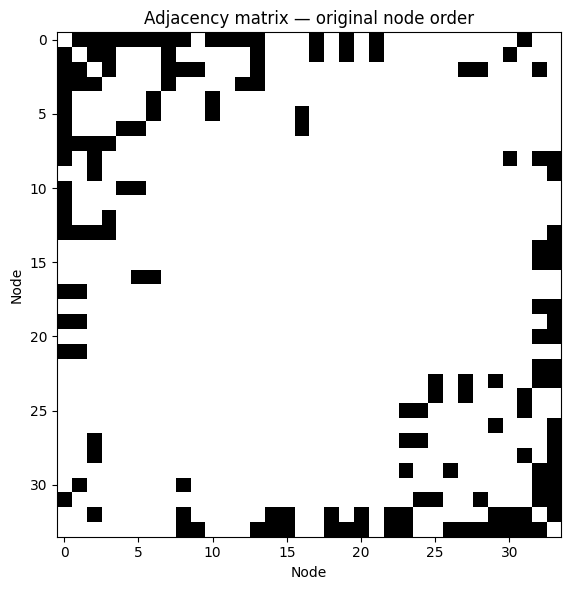

In [5]:
plt.figure(figsize=(6, 6))
plt.imshow(A, cmap="Greys", interpolation="nearest")
plt.title("Adjacency matrix — original node order")
plt.xlabel("Node"); plt.ylabel("Node")
plt.tight_layout(); plt.show()

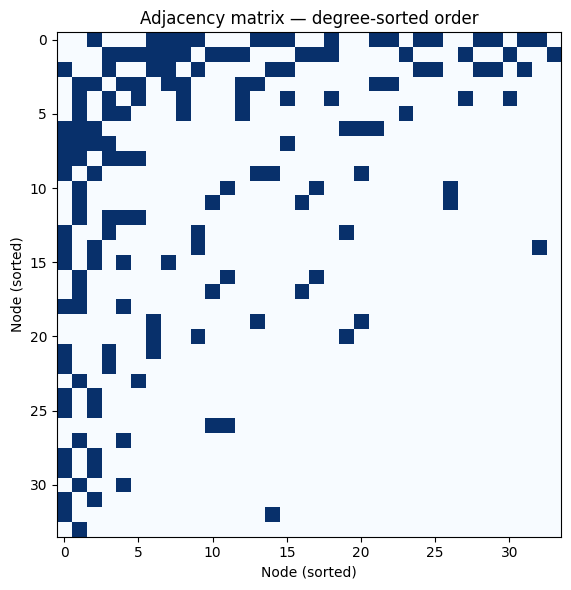

In [6]:
# Reorder nodes by degree for clearer block patterns
deg_sorted_nodes = [n for n, _ in sorted(G.degree, key=lambda x: x[1], reverse=True)]
A_deg = nx.to_numpy_array(G, nodelist=deg_sorted_nodes, dtype=int)

plt.figure(figsize=(6, 6))
plt.imshow(A_deg, cmap="Blues", interpolation="nearest")
plt.title("Adjacency matrix — degree-sorted order")
plt.xlabel("Node (sorted)"); plt.ylabel("Node (sorted)")
plt.tight_layout(); plt.show()

## 3) Implicit presentation: Treemap & Sunburst

In [7]:
hier = pd.DataFrame({
    "division": ["Product", "Product", "Product", "Service", "Service", "Service"],
    "team": ["Mobile", "Web", "Data", "Support", "Consulting", "Training"],
    "project": ["App A", "Site B", "Pipeline C", "Helpdesk", "Client X", "Workshop"],
    "value": [120, 90, 70, 60, 85, 40],
})
hier

,division,team,project,value
0,Product,Mobile,App A,120
1,Product,Web,Site B,90
2,Product,Data,Pipeline C,70
3,Service,Support,Helpdesk,60
4,Service,Consulting,Client X,85
5,Service,Training,Workshop,40


In [8]:
fig_t = px.treemap(
    hier,
    path=["division", "team", "project"],
    values="value",
    color="value",
    color_continuous_scale="Viridis",
    title="Treemap: implicit hierarchy with area encoding",
)
fig_t.show()

/Users/trungtv/miniforge3/lib/python3.10/site-packages/kaleido/__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [9]:
fig_s = px.sunburst(
    hier,
    path=["division", "team", "project"],
    values="value",
    color="division",
    title="Sunburst: radial implicit hierarchy",
)
fig_s.show()

## 4) So sánh nhanh các biểu diễn

In [10]:
comparison = pd.DataFrame({
    "representation": ["Tree layout", "Adjacency matrix", "Treemap", "Sunburst"],
    "best_for": [
        "Path/ancestor-descendant reasoning",
        "Dense connectivity patterns, block structure",
        "Part-to-whole + hierarchy with screen efficiency",
        "Part-to-whole hierarchy in radial storytelling",
    ],
    "limitations": [
        "Can clutter with many nodes",
        "Hard to trace individual paths",
        "Area comparison not as precise as bars",
        "Angle/area perception less accurate",
    ],
})
comparison

,representation,best_for,limitations
0,Tree layout,Path/ancestor-descendant reasoning,Can clutter with many nodes
1,Adjacency matrix,"Dense connectivity patterns, block structure",Hard to trace individual paths
2,Treemap,Part-to-whole + hierarchy with screen efficiency,Area comparison not as precise as bars
3,Sunburst,Part-to-whole hierarchy in radial storytelling,Angle/area perception less accurate


## Reflection
- Khi nào tree layout tốt hơn treemap/sunburst?
- Khi graph dày cạnh, adjacency matrix giúp gì tốt hơn node-link?
- Với dashboard business, bạn chọn treemap hay sunburst và vì sao?